# Similarity-Based Learning: Mushroom Classification & MovieLens User Similarity

### K-Nearest Neighbors, Distance Metrics, and Collaborative Filtering

This notebook explores two applications of similarity-based learning:

1. **Mushroom classification** using K-Nearest Neighbors (KNN)
2. **User similarity** in MovieLens using cosine distance

The first section examines class balance, encoded-feature relationships, neighborhood size, and alternative distance metrics. The second constructs a user-item matrix and retrieves users with similar rating profiles.

**Data availability:** The original Mushroom and MovieLens CSV files are not included in this portfolio archive. Existing tables, plots, and printed results are preserved from the original execution.

In [1]:
# IMPORT YOUR REQUIRED LIBRARIES HERE

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from ucimlrepo import fetch_ucirepo 
from matplotlib.colors import LinearSegmentedColormap

# Part I — Mushroom Classification

## 1. Data Loading and Cleaning

The Mushroom dataset contains categorical descriptors such as cap shape, odor, gill characteristics, stalk properties, habitat, and an edible/poisonous target.

The archived workflow:

- loads a local CSV;
- inspects missing values;
- fills missing `stalk-root` values with the modal category;
- maps short categorical codes to descriptive labels; and
- removes the constant `veil-type` feature before modeling.

In [2]:
# shrooms.to_csv("mushrooms.csv", index=False)
shrooms = pd.read_csv("mushrooms.csv")
shrooms.head()

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,poisonous
0,x,s,n,t,p,f,c,n,k,e,...,w,w,p,w,o,p,k,s,u,p
1,x,s,y,t,a,f,c,b,k,e,...,w,w,p,w,o,p,n,n,g,e
2,b,s,w,t,l,f,c,b,n,e,...,w,w,p,w,o,p,n,n,m,e
3,x,y,w,t,p,f,c,n,n,e,...,w,w,p,w,o,p,k,s,u,p
4,x,s,g,f,n,f,w,b,k,t,...,w,w,p,w,o,e,n,a,g,e


In [3]:
missing_values = shrooms.isnull().sum()
print("Missing Values in Each Column:")
print(missing_values)

Missing Values in Each Column:
cap-shape                      0
cap-surface                    0
cap-color                      0
bruises                        0
odor                           0
gill-attachment                0
gill-spacing                   0
gill-size                      0
gill-color                     0
stalk-shape                    0
stalk-root                  2480
stalk-surface-above-ring       0
stalk-surface-below-ring       0
stalk-color-above-ring         0
stalk-color-below-ring         0
veil-type                      0
veil-color                     0
ring-number                    0
ring-type                      0
spore-print-color              0
population                     0
habitat                        0
poisonous                      0
dtype: int64


In [4]:
most_common_value = shrooms["stalk-root"].mode()[0]
shrooms["stalk-root"] = shrooms["stalk-root"].fillna(most_common_value)

In [5]:
# create mapping dictionaties

descriptions = {
    
    "poisonous": {
        "p": "poisonous",
        "e": "edible"
    },
    "cap-shape": {
        "b": "bell",
        "c": "conical",
        "x": "convex",
        "f": "flat",
        "k": "knobbed",
        "s": "sunken"
    },
    "cap-surface": {
        "f": "fibrous",
        "g": "grooves",
        "y": "scaly",
        "s": "smooth"
    },
    "cap-color": {
        "n": "brown",
        "b": "buff",
        "c": "cinnamon",
        "g": "gray",
        "r": "green",
        "p": "pink",
        "u": "purple",
        "e": "red",
        "w": "white",
        "y": "yellow"
    },
    "bruises": {
        "t": "bruises",
        "f": "no"
    },
    "odor": {
        "a": "almond",
        "l": "anise",
        "c": "creosote",
        "y": "fishy",
        "f": "foul",
        "m": "musty",
        "n": "none",
        "p": "pungent",
        "s": "spicy"
    },
    "gill-attachment": {
        "a": "attached",
        "d": "descending",
        "f": "free",
        "n": "notched"
    },
    "gill-spacing": {
        "c": "close",
        "w": "crowded",
        "d": "distant"
    },
    "gill-size": {
        "b": "broad",
        "n": "narrow"
    },
    "gill-color": {
        "k": "black",
        "n": "brown",
        "b": "buff",
        "h": "chocolate",
        "g": "gray",
        "r": "green",
        "o": "orange",
        "p": "pink",
        "u": "purple",
        "e": "red",
        "w": "white",
        "y": "yellow"
    },
    "stalk-shape": {
        "e": "enlarging",
        "t": "tapering"
    },
    "stalk-root": {
        "b": "bulbous",
        "c": "club",
        "u": "cup",
        "e": "equal",
        "z": "rhizomorphs",
        "r": "rooted",
    },
    "stalk-surface-above-ring": {
        "f": "fibrous",
        "y": "scaly",
        "k": "silky",
        "s": "smooth"
    },
    "stalk-surface-below-ring": {
        "f": "fibrous",
        "y": "scaly",
        "k": "silky",
        "s": "smooth"
    },
    "stalk-color-above-ring": {
        "n": "brown",
        "b": "buff",
        "c": "cinnamon",
        "g": "gray",
        "o": "orange",
        "p": "pink",
        "e": "red",
        "w": "white",
        "y": "yellow"
    },
    "stalk-color-below-ring": {
        "n": "brown",
        "b": "buff",
        "c": "cinnamon",
        "g": "gray",
        "o": "orange",
        "p": "pink",
        "e": "red",
        "w": "white",
        "y": "yellow"
    },
    "veil-type": {
        "p": "partial",
        "u": "universal"
    },
    "veil-color": {
        "n": "brown",
        "o": "orange",
        "w": "white",
        "y": "yellow"
    },
    "ring-number": {
        "n": "none",
        "o": "one",
        "t": "two"
    },
    "ring-type": {
        "c": "cobwebby",
        "e": "evanescent",
        "f": "flaring",
        "l": "large",
        "n": "none",
        "p": "pendant",
        "s": "sheathing",
        "z": "zone"
    },
    "spore-print-color": {
        "k": "black",
        "n": "brown",
        "b": "buff",
        "h": "chocolate",
        "r": "green",
        "o": "orange",
        "u": "purple",
        "w": "white",
        "y": "yellow"
    },
    "population": {
        "a": "abundant",
        "c": "clustered",
        "n": "numerous",
        "s": "scattered",
        "v": "several",
        "y": "solitary"
    },
    "habitat": {
        "g": "grasses",
        "l": "leaves",
        "m": "meadows",
        "p": "paths",
        "u": "urban",
        "w": "waste",
        "d": "woods"
    }
}

In [6]:
for col, mapping in descriptions.items():
    if col in shrooms.columns:
        shrooms[col] = shrooms[col].map(mapping)

shrooms

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,poisonous
0,convex,smooth,brown,bruises,pungent,free,close,narrow,black,enlarging,...,white,white,partial,white,one,pendant,black,scattered,urban,poisonous
1,convex,smooth,yellow,bruises,almond,free,close,broad,black,enlarging,...,white,white,partial,white,one,pendant,brown,numerous,grasses,edible
2,bell,smooth,white,bruises,anise,free,close,broad,brown,enlarging,...,white,white,partial,white,one,pendant,brown,numerous,meadows,edible
3,convex,scaly,white,bruises,pungent,free,close,narrow,brown,enlarging,...,white,white,partial,white,one,pendant,black,scattered,urban,poisonous
4,convex,smooth,gray,no,none,free,crowded,broad,black,tapering,...,white,white,partial,white,one,evanescent,brown,abundant,grasses,edible
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,knobbed,smooth,brown,no,none,attached,close,broad,yellow,enlarging,...,orange,orange,partial,orange,one,pendant,buff,clustered,leaves,edible
8120,convex,smooth,brown,no,none,attached,close,broad,yellow,enlarging,...,orange,orange,partial,brown,one,pendant,buff,several,leaves,edible
8121,flat,smooth,brown,no,none,attached,close,broad,brown,enlarging,...,orange,orange,partial,orange,one,pendant,buff,clustered,leaves,edible
8122,knobbed,scaly,brown,no,fishy,free,close,narrow,buff,tapering,...,white,white,partial,white,one,evanescent,white,several,leaves,poisonous


### Cleaned Dataset Preview

In [7]:
# INSERT CODE HERE
shrooms.head()

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,poisonous
0,convex,smooth,brown,bruises,pungent,free,close,narrow,black,enlarging,...,white,white,partial,white,one,pendant,black,scattered,urban,poisonous
1,convex,smooth,yellow,bruises,almond,free,close,broad,black,enlarging,...,white,white,partial,white,one,pendant,brown,numerous,grasses,edible
2,bell,smooth,white,bruises,anise,free,close,broad,brown,enlarging,...,white,white,partial,white,one,pendant,brown,numerous,meadows,edible
3,convex,scaly,white,bruises,pungent,free,close,narrow,brown,enlarging,...,white,white,partial,white,one,pendant,black,scattered,urban,poisonous
4,convex,smooth,gray,no,none,free,crowded,broad,black,tapering,...,white,white,partial,white,one,evanescent,brown,abundant,grasses,edible


## 2. Target-Class Balance

The stored dataset contains:

- **4,208 edible mushrooms**
- **3,916 poisonous mushrooms**

This corresponds to approximately **51.8% edible** and **48.2% poisonous**, with a proportional-chance criterion of approximately **0.5006**. The target is therefore close to balanced, so class imbalance is not a major concern for this exercise.

Class Distribution:
poisonous
edible       4208
poisonous    3916
Name: count, dtype: int64

Class Proportions:
poisonous
edible       0.517971
poisonous    0.482029
Name: count, dtype: float64

Proportional Chance Criterion (PCC): 0.5006459455010605


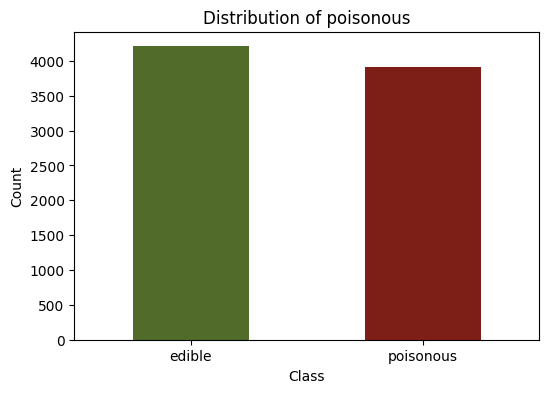

In [8]:
# INSERT YOUR CODE HERE
target_col = "poisonous"

# Calculate the distribution of the target classes
class_counts = shrooms[target_col].value_counts()
class_proportions = class_counts / class_counts.sum()

# Calculate the Proportional Chance Criterion (PCC)
# PCC is the sum of squared class proportions
pcc = sum(class_proportions ** 2)

print("Class Distribution:")
print(class_counts)
print("\nClass Proportions:")
print(class_proportions)
print("\nProportional Chance Criterion (PCC):", pcc)

# Plot
plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar", color=["#516B2B", "#7E1F17"])
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Distribution of {}".format(target_col))
plt.xticks(rotation=0)
plt.show()

## 3. Encoded-Feature Correlation View

The categorical variables are converted to integer category codes and a Pearson correlation matrix is calculated. The archived run reports **no feature pair with absolute correlation greater than 0.9**.

Because the predictors are nominal categorical variables, these numeric codes impose arbitrary ordering. The resulting Pearson correlations should therefore be treated as a visualization of the encoded representation—not as definitive semantic correlations or a complete multicollinearity diagnostic.

In [9]:
shrooms = shrooms.drop(columns=["veil-type"])

In [10]:
## INSERT CODE
shrooms2 = shrooms.apply(lambda col: col.astype('category').cat.codes)
corr_matrix = shrooms2.corr()

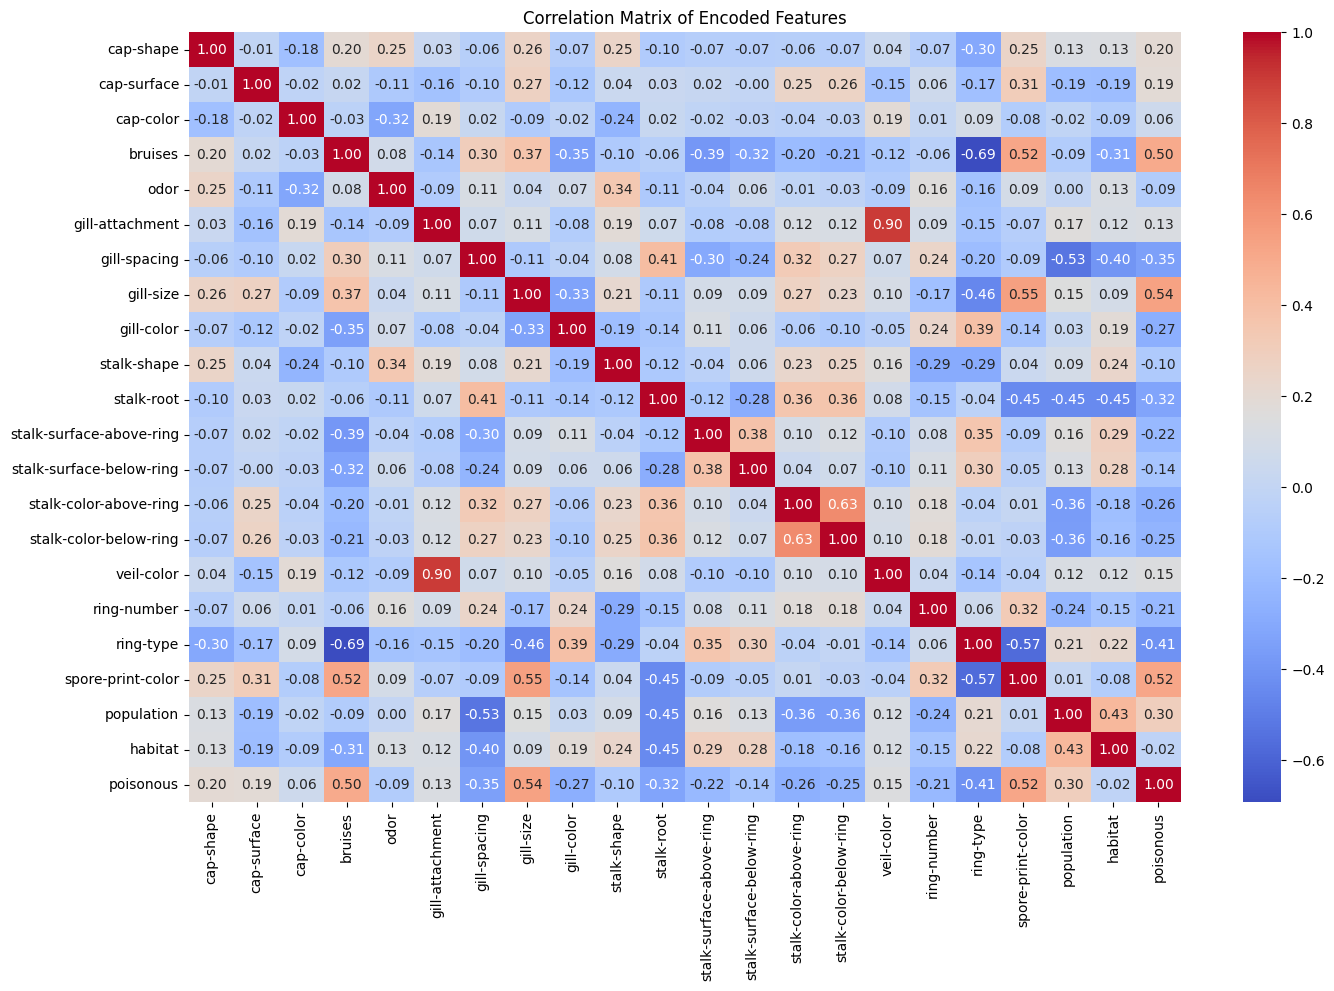

In [11]:
plt.figure(figsize=(16, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix of Encoded Features")
plt.show()

In [12]:
high_corr_pairs = []
cols = corr_matrix.columns

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):  # skip duplicates and self-correlation
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            high_corr_pairs.append((cols[i], cols[j], corr_matrix.iloc[i, j]))

if not high_corr_pairs:
    print("No pairs found with correlation > 0.9")
else:
    print("Pairs of features with correlation > 0.9:")
    for col1, col2, corr_value in high_corr_pairs:
        print(f"{col1} & {col2} = {corr_value:.2f}")

No pairs found with correlation > 0.9


## 4. Baseline KNN Classifier

An 80/20 train-test split is created with a fixed random state. A 5-neighbor KNN classifier using Euclidean distance is then fitted.

The preserved run reports a **training accuracy of 0.99985**.

In [13]:
### INSERT CODE
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

# Separate features and target
X = shrooms2.drop("poisonous", axis=1)
y = shrooms2["poisonous"]

# Perform an 80%-20% split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=69)

# Initialize a KNN classifier with 5 neighbors using Euclidean distance
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')

# Fit the classifier on the training data
knn.fit(X_train, y_train)

# Calculate and print the training accuracy
train_accuracy = knn.score(X_train, y_train)
print("Training accuracy:", train_accuracy)

Training accuracy: 0.9998461301738729


## 5. Neighborhood-Size Sweep

The notebook compares training and test accuracy for \(k=1\) through \(k=20\).

The stored heuristic reports:

- maximum training accuracy at **\(k=1\)**;
- highest sub-1.0 training accuracy at **\(k=4\)**; and
- an "elbow" selection of **\(k=20\)** based on the code's change-in-test-accuracy rule.

The final item should be interpreted cautiously: the implemented rule is not a standard elbow criterion for KNN model selection. In practice, \(k\) would normally be selected using validation or cross-validation performance.

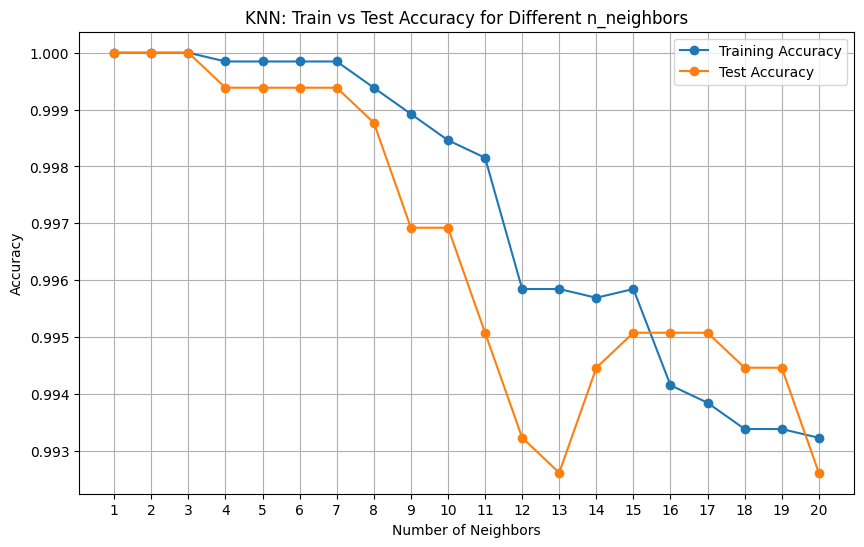

Elbow Method suggests optimal n_neighbors = 20
Maximum training accuracy is achieved at n_neighbors = 1
Highest training accuracy (excluding 1.0) is 0.9998 at n_neighbors = 4


In [14]:
train_accuracies = []
test_accuracies = []
neighbors = range(1, 21)

# Loop over n_neighbors from 1 to 20
for n in neighbors:
    knn = KNeighborsClassifier(n_neighbors=n, metric='euclidean')
    knn.fit(X_train, y_train)
    
    # Calculate accuracy on training and test data
    train_acc = knn.score(X_train, y_train)
    test_acc = knn.score(X_test, y_test)
    
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

plt.figure(figsize=(10, 6))
plt.plot(neighbors, train_accuracies, marker='o', label='Training Accuracy')
plt.plot(neighbors, test_accuracies, marker='o', label='Test Accuracy')
plt.xlabel('Number of Neighbors')
plt.ylabel('Accuracy')
plt.title('KNN: Train vs Test Accuracy for Different n_neighbors')
plt.xticks(neighbors)
plt.grid(True)
plt.legend()
plt.show()

accuracy_diff = np.diff(test_accuracies)
elbow_n = neighbors[np.argmin(accuracy_diff) + 1]

print(f"Elbow Method suggests optimal n_neighbors = {elbow_n}")

# Determine the best k using original method
best_train_n = neighbors[train_accuracies.index(max(train_accuracies))]
print("Maximum training accuracy is achieved at n_neighbors =", best_train_n)

# Additional: Find the highest n_neighbors excluding accuracy of 1.0
valid_train_accuracies = [(n, acc) for n, acc in zip(neighbors, train_accuracies) if acc < 1.0]

if valid_train_accuracies:
    best_train_n_excluding_1, best_train_acc_excluding_1 = max(valid_train_accuracies, key=lambda x: x[1])
    print(f"Highest training accuracy (excluding 1.0) is {best_train_acc_excluding_1:.4f} at n_neighbors = {best_train_n_excluding_1}")
else:
    print("All training accuracies are 1.0, no best n_neighbors below 1.0 found.")

## 6. Distance-Metric Comparison

The stored run evaluates Euclidean, Manhattan/Cityblock, Minkowski (\(p=3\)), and Cosine distance at several neighborhood sizes.

| Neighborhood size | Euclidean test | Cityblock test | Minkowski \(p=3\) test | Cosine test |
|---:|---:|---:|---:|---:|
| 1 | 1.0000 | 1.0000 | 1.0000 | 1.0000 |
| 4 | 0.9994 | 1.0000 | 0.9988 | 0.9994 |
| 20 | 0.9926 | 0.9988 | 0.9908 | 0.9920 |

These results show extremely strong separability in the stored representation. However, the categorical features were converted to integer codes before KNN, which means Euclidean-like distance metrics treat arbitrary category numbers as geometrically meaningful. A stronger production approach would use one-hot encoding or a distance measure designed for categorical/mixed data.

In [15]:
### Question 6

from sklearn.metrics import accuracy_score

best_n = best_train_n
best_n_excluding_1 = best_train_n_excluding_1
best_n_elbow = elbow_n

metrics = {
    'Euclidean': {'metric': 'euclidean'},
    'Cityblock': {'metric': 'manhattan'},
    'Minkowski (p=3)': {'metric': 'minkowski', 'p': 3},
    'Cosine': {'metric': 'cosine'}
}

def evaluate_knn(n_neighbors):
    train_acc_dict = {}
    test_acc_dict = {}

    for metric_name, params in metrics.items():
        knn = KNeighborsClassifier(n_neighbors=n_neighbors, **params)
        knn.fit(X_train, y_train)

        train_acc = knn.score(X_train, y_train)
        test_acc = knn.score(X_test, y_test)

        train_acc_dict[metric_name] = train_acc
        test_acc_dict[metric_name] = test_acc

        print(f"Metric: {metric_name} (n_neighbors={n_neighbors})")
        print(f"   Training Accuracy: {train_acc:.4f}")
        print(f"   Test Accuracy: {test_acc:.4f}\n")

    return train_acc_dict, test_acc_dict

print(f"--- Evaluating Best n_neighbors ({best_n}) ---")
train_acc_best, test_acc_best = evaluate_knn(best_n)

print(f"\n--- Evaluating Best n_neighbors Excluding 1.0 Accuracy ({best_n_excluding_1}) ---")
train_acc_excl_1, test_acc_excl_1 = evaluate_knn(best_n_excluding_1)

print(f"\n--- Evaluating Best n_neighbors from Elbow Method ({best_n_elbow}) ---")
train_acc_elbow, test_acc_elbow = evaluate_knn(best_n_elbow)


--- Evaluating Best n_neighbors (1) ---
Metric: Euclidean (n_neighbors=1)
   Training Accuracy: 1.0000
   Test Accuracy: 1.0000

Metric: Cityblock (n_neighbors=1)
   Training Accuracy: 1.0000
   Test Accuracy: 1.0000

Metric: Minkowski (p=3) (n_neighbors=1)
   Training Accuracy: 1.0000
   Test Accuracy: 1.0000

Metric: Cosine (n_neighbors=1)
   Training Accuracy: 1.0000
   Test Accuracy: 1.0000


--- Evaluating Best n_neighbors Excluding 1.0 Accuracy (4) ---
Metric: Euclidean (n_neighbors=4)
   Training Accuracy: 0.9998
   Test Accuracy: 0.9994

Metric: Cityblock (n_neighbors=4)
   Training Accuracy: 1.0000
   Test Accuracy: 1.0000

Metric: Minkowski (p=3) (n_neighbors=4)
   Training Accuracy: 0.9997
   Test Accuracy: 0.9988

Metric: Cosine (n_neighbors=4)
   Training Accuracy: 0.9998
   Test Accuracy: 0.9994


--- Evaluating Best n_neighbors from Elbow Method (20) ---
Metric: Euclidean (n_neighbors=20)
   Training Accuracy: 0.9932
   Test Accuracy: 0.9926

Metric: Cityblock (n_neighbo

# Part II — MovieLens User Similarity

## 7. MovieLens Data

The second half loads MovieLens movie, rating, tag, and link files. The ratings are combined with movie titles to create a user-item matrix where rows represent users, columns represent films, and values represent ratings.

In [16]:
movies = pd.read_csv("movies.csv")
ratings = pd.read_csv("ratings.csv")
tags = pd.read_csv("tags.csv")
links = pd.read_csv("links.csv")

# Display the first few rows of each dataset
print("Movies Dataset:")
display(movies.head())

print("\nRatings Dataset:")
display(ratings.head())

print("\nTags Dataset:")
display(tags.head())

print("\nLinks Dataset:")
display(links.head())


Movies Dataset:


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy



Ratings Dataset:


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931



Tags Dataset:


,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200



Links Dataset:


,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


## 8. User-Item Matrix

In [17]:
# Merge movies and ratings on 'movieId'
movie_ratings = pd.merge(ratings, movies, on="movieId")

# Create a User-Item Matrix (rows: users, columns: movies, values: ratings)
user_item_matrix = movie_ratings.pivot_table(index="userId", columns="title", values="rating", fill_value=0)


# Display a sample of the user-item matrix
print("User-Item Matrix:")
display(user_item_matrix.head())

User-Item Matrix:


title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997),'Tis the Season for Love (2015),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),*batteries not included (1987),...,Zulu (2013),[REC] (2007),[REC]² (2009),[REC]³ 3 Génesis (2012),anohana: The Flower We Saw That Day - The Movie (2013),eXistenZ (1999),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931)
userId,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 9. Cosine Distance

For user vectors \(u\) and \(v\):

\[
\text{cosine similarity}(u,v)=
\frac{u\cdot v}{\|u\|\|v\|}
\]

and

\[
\text{cosine distance}(u,v)=1-\text{cosine similarity}(u,v).
\]

Smaller values indicate more similar rating directions.

In [18]:
def cosine_distance(u, v):
    dot_product = np.dot(u, v)
    norm_u = np.linalg.norm(u)
    norm_v = np.linalg.norm(v)
    if norm_u == 0 or norm_v == 0:
        return 1  # Max distance if either user has no ratings at all
    
    cosine_sim = dot_product / (norm_u * norm_v)
    return 1 - cosine_sim

## 10. Nearest Users

The `similar_users` function compares a selected user's rating vector against every other user and returns the ten smallest cosine distances.

For **user 1**, the stored run identifies users **266, 313, 368, 57, 91, 469, 39, 288, 452, and 45** as the nearest profiles under this representation.

In [19]:
def similar_users(userid, user_item_matrix, top_n=10):
    user_vector = user_item_matrix.loc[userid].values
    
    distances = []

    for other_userid in user_item_matrix.index:
        if other_userid != userid:
            other_user_vector = user_item_matrix.loc[other_userid].values
            dist = cosine_distance(user_vector, other_user_vector)
            distances.append((other_userid, dist))

    distances.sort(key=lambda x: x[1])

    return distances[:top_n]

top_10_similar = similar_users(userid=1, user_item_matrix=user_item_matrix, top_n=10)
print(top_10_similar)


[(266, np.float64(0.6425922903967258)), (313, np.float64(0.6484384815090432)), (368, np.float64(0.6548729484164695)), (57, np.float64(0.6549657211924163)), (91, np.float64(0.6652730795818292)), (469, np.float64(0.669335684934799)), (39, np.float64(0.6702177663424733)), (288, np.float64(0.6703004707170711)), (452, np.float64(0.6719516555754712)), (45, np.float64(0.6720783102227796))]


## 11. Limitations and Takeaways

### Mushroom KNN

- Integer encoding of nominal categories creates artificial numeric distances.
- Feature scaling/encoding choices strongly affect KNN geometry.
- The near-perfect accuracy should therefore be interpreted as an educational result on a highly separable dataset, not proof that a particular distance metric is universally superior.

### MovieLens Similarity

- Missing ratings are represented as zeros in the user-item matrix.
- Cosine distance therefore compares many unrated entries alongside observed ratings.
- More mature recommenders can restrict similarity to co-rated items, apply significance weighting, center ratings by user, or use latent-factor methods.

Together, the two sections demonstrate how the concept of **distance/similarity** can support both supervised classification and recommender-system analysis.